In [8]:
import pandas as pd

df = pd.read_csv("data/listings.csv", low_memory = False)#para ler o ficheiro duma vez sem correr o risco de confundir
 
#numero de linhas e colunas
print(df.shape)

#nome, tipo e numero de valores nao nulos em cada coluna 
df.info()

#percentagem de valores em falta por coluna 
missing = (df.isna().mean() * 100).sort_values(ascending = False)
print(missing[missing > 0].round(1).to_string())

print(df["price"].dtype)
print(df["price"].head(10))

(6734, 90)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6734 entries, 0 to 6733
Data columns (total 90 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            6734 non-null   int64  
 1   listing_url                                   6734 non-null   object 
 2   scrape_id                                     6734 non-null   int64  
 3   last_scraped                                  6734 non-null   object 
 4   source                                        6734 non-null   object 
 5   name                                          6734 non-null   object 
 6   description                                   6627 non-null   object 
 7   neighborhood_overview                         0 non-null      float64
 8   picture_url                                   6733 non-null   object 
 9   host_id                                       6734 n

In [11]:
df["price_num"] = df["price"].str.replace(r"[$,]", "", regex=True).astype(float)

# número de noites da estadia simulada
df["noites"] = (pd.to_datetime(df["price_quote_checkout_date"])
                - pd.to_datetime(df["price_quote_checkin_date"])).dt.days

print(df[["price_num", "price_quote_total_price",
          "price_quote_price_per_night", "noites"]].head(10))
print(df["noites"].value_counts().head())
print(df["price_quote_price_per_night"].describe())

   price_num  price_quote_total_price  price_quote_price_per_night  noites
0    1181.02                 21258.28                      1181.02    18.0
1     822.05                 16441.00                       822.05    20.0
2        NaN                      NaN                          NaN     NaN
3   24910.60                249106.00                     24910.60    10.0
4    1077.87                 32335.99                      1077.87    30.0
5    1746.00                  1746.00                      1746.00     1.0
6     138.82                 12494.13                       138.82    90.0
7     216.00                   216.00                       216.00     1.0
8     127.85                 11506.08                       127.85    90.0
9     216.00                   216.00                       216.00     1.0
noites
1.0     1909
29.0    1012
30.0     897
28.0     498
3.0      434
Name: count, dtype: int64
count      6046.000000
mean        790.401667
std        2699.565444
min     

In [9]:
df["last_scraped"].unique()

array(['2026-06-28', '2026-07-03', '2026-06-29'], dtype=object)

In [14]:
# Ficar apenas com linhas que têm preço
d = df.dropna(subset=["price_num"]).copy()
print(d.shape)
print(d["price_num"].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]))

#dividir números de noites para ditar preços
d["grupo_noites"] = pd.cut(d["noites"],
                           bins=[0, 1, 7, 27, 31, 1000],
                           labels=["1", "2-7", "8-27", "28-31", "32+"])
#agrupa as linhas por grupo_noites olhando para a coluna price_num
#usei observed para evitar aviso do pandas quando se agrupa categorias
print(d.groupby("grupo_noites", observed=True)["price_num"].agg(["count", "median", "mean"]).round(1))


(6046, 92)
0.010       97.85300
0.050      169.60750
0.250      225.94750
0.500      424.00000
0.750      883.08500
0.950     2187.98000
0.990     4618.87500
0.999    23142.74805
Name: price_num, dtype: float64
              count  median    mean
grupo_noites                       
1              1882   545.0   982.6
2-7            1266   901.5  1267.3
8-27            227   673.9  1174.7
28-31          2535   221.3   407.1
32+             136   120.7   194.6


Linhas: 1882


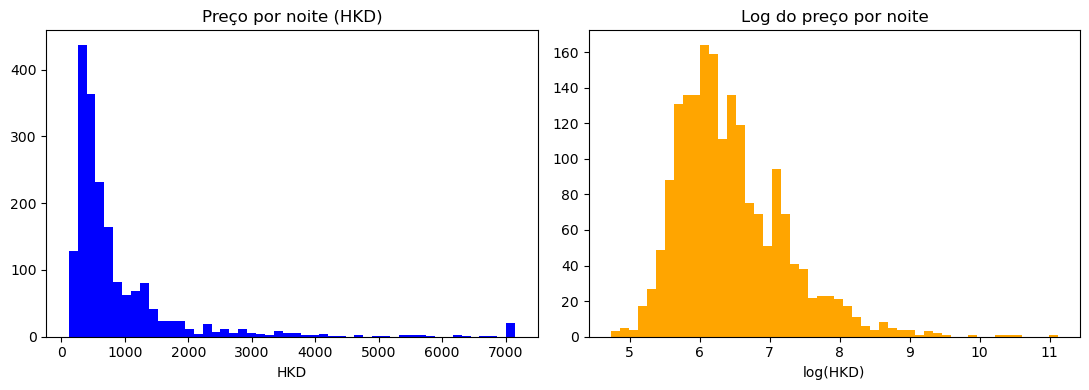

In [19]:
import matplotlib.pyplot as plt
import numpy as np
# Ficar só com estadias de 1 noite
d1 = d[d["noites"] == 1].copy()
print("Linhas:", len(d1))

# Dois histogramas lado a lado
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

# Preço bruto, cortado no percentil 99 só para o gráfico ser legível
limite = d1["price_num"].quantile(0.99)
ax[0].hist(d1["price_num"].clip(upper=limite), bins=50, color="blue")
ax[0].set_title("Preço por noite (HKD)")
ax[0].set_xlabel("HKD")

# Log do preço
ax[1].hist(np.log(d1["price_num"]), bins=50, color="orange")
ax[1].set_title("Log do preço por noite")
ax[1].set_xlabel("log(HKD)")

plt.tight_layout()
plt.savefig("figures/preco_vs_log_preco.png", dpi=150, bbox_inches="tight")
plt.show()

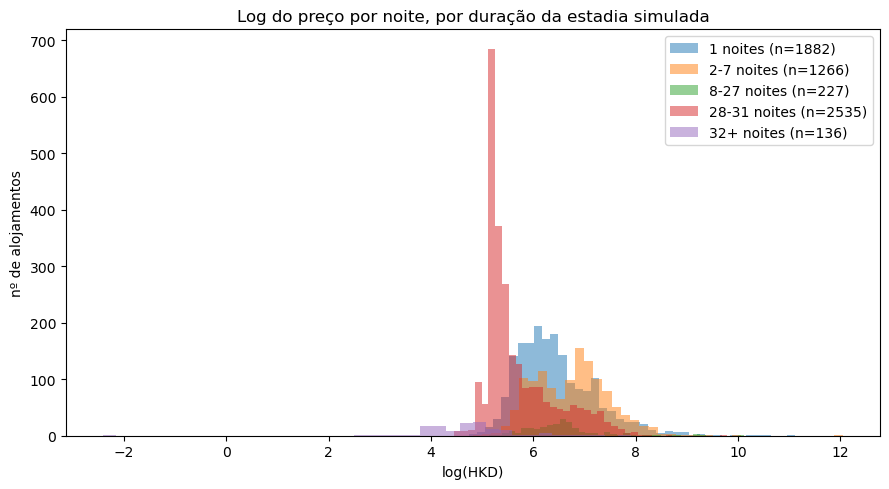

In [20]:
#separar os histogramas do log-preço por grupo de duração

fig, ax = plt.subplots(1, 1, figsize=(9, 5))
#ciclo para percorrer cada grupo da lista

for grupo in ["1", "2-7", "8-27", "28-31", "32+"]:
    #apenas linhas de um dado grupo
    subset = d[d["grupo_noites"] == grupo]
    ax.hist(np.log(subset["price_num"]), bins=40, alpha=0.5, label=f"{grupo} noites (n={len(subset)})")

ax.set_title("Log do preço por noite, por duração da estadia simulada")
ax.set_xlabel("log(HKD)")
ax.set_ylabel("nº de alojamentos")
ax.legend()

plt.tight_layout()
plt.savefig("figures/log_preco_por_duracao.png", dpi=150, bbox_inches="tight")
plt.show()

In [22]:
#como o preço se relaciona em relação ao tipo de quarto,capacidade e bairro
#preço por tipo de quarto
print(d.groupby("room_type")["price_num"].agg(["count", "median", "mean"]).round(1))

#preco por capacidade
print(d.groupby("accommodates")["price_num"].agg(["count","median","mean"]).round(1))

#Top15 bairros  com mais alojamentos, com o preco mediano
print(d.groupby("neighbourhood_cleansed")["price_num"].agg(["count", "median"]).sort_values("count", ascending=False).head(15).round(1))

                 count  median    mean
room_type                             
Entire home/apt   2209   987.0  1398.2
Hotel room          15   366.0   675.1
Private room      3706   292.1   444.3
Shared room        116   225.0   287.8
              count  median    mean
accommodates                       
1              1628   223.3   327.1
2              2746   393.8   592.8
3               454   664.0  1307.3
4               477   906.9  1150.0
5               155  1256.0  1522.5
6               245  1327.4  1870.4
7                82  1348.3  1815.7
8               124  1386.0  1681.5
9                24  1629.4  1751.6
10               48  1641.2  1732.8
11               14  2187.0  2324.2
12               12  1321.7  4108.9
13                2  1911.8  1911.8
14                5  3021.7  3203.4
15                5  2569.7  3680.0
16               25  2454.0  7171.8
                        count  median
neighbourhood_cleansed               
Yau Tsim Mong            2430   413.0
Wan 